In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
from scipy.ndimage import gaussian_filter1d
import tensorflow as tf

In [2]:
font_path = 'C:\\Users\\laber\\AppData\\Local\\Microsoft\\Windows\\Fonts\\LinLibertine_R.ttf'
font_manager.fontManager.addfont(font_path)
plt.rcParams.update({
    "text.usetex": False,           
    "font.family": "serif",
    "font.serif": ["Linux Libertine"]
})

In [31]:
def plot_bars_performance(title, tpn_means, tpn_std, sincnet_means, sincnet_std):
    
    groups = ['Linear Evaluation', 'Fine-Tuned Evaluation']
    x = np.arange(len(groups))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 7))

    # 1. Create Grouped Bars
    rects1 = ax.bar(x - width/2, tpn_means, width, yerr=tpn_std, label='TPN', 
                    capsize=10, color="#ffc845", alpha=0.8, edgecolor='black')
    rects2 = ax.bar(x + width/2, sincnet_means, width, yerr=sincnet_std, label='TPN + SincNet', 
                    capsize=10, color='#1b365d', alpha=0.8, edgecolor='black')

    # 2. Formatting & Font Sizes
    ax.set_title(title, fontsize=24, pad=20)
    ax.set_ylabel('Weighted F1 Score', fontsize=20)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylim(0.5, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # 3. Add Legend
    ax.legend(fontsize=14, loc='upper right')

    # 4. Helper function for labels
    def autolabel(rects, stds):
        for i, rect in enumerate(rects):
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height + stds[i] + 0.01),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=20, fontweight='bold')

    autolabel(rects1, tpn_std)
    autolabel(rects2, sincnet_std)

    plt.tight_layout()
    plt.show()

DEBUG:matplotlib.font_manager:findfont: Matching serif:style=normal:variant=normal:weight=bold:stretch=normal:size=20.0.
DEBUG:matplotlib.font_manager:findfont: Matching serif:style=normal:variant=normal:weight=bold:stretch=normal:size=20.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\laber\\MASc\\Repos\\ContrastiveLearningHAR\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\laber\\MASc\\Repos\\ContrastiveLearningHAR\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\laber\\MASc\\Repos\\ContrastiveLearningHAR\\.venv\\Lib\\site-packages\

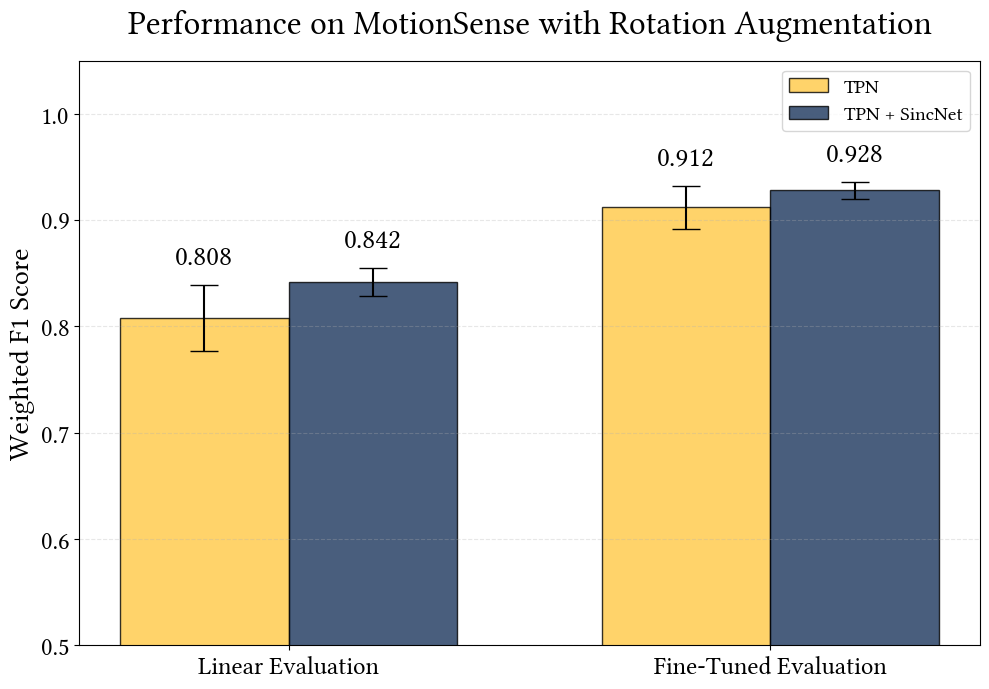

In [32]:
# MotionSense Rotation
plot_bars_performance(
    title='Performance on MotionSense with Rotation Augmentation',
    tpn_means=[0.808, 0.912],
    tpn_std=[0.031, 0.020],
    sincnet_means=[0.842, 0.928],
    sincnet_std=[0.013, 0.008]
)

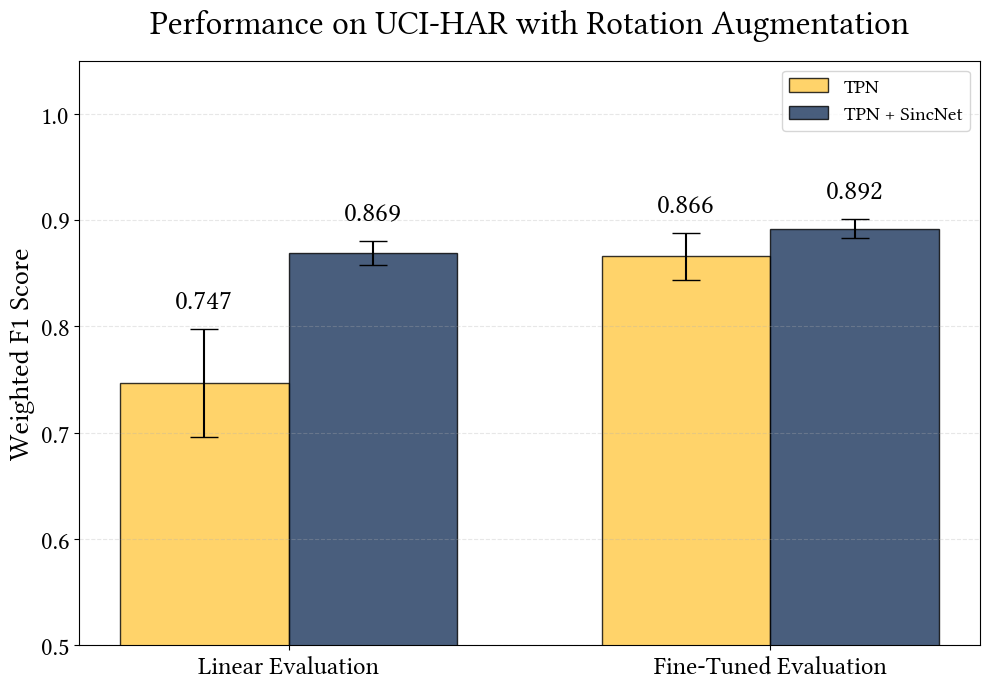

In [34]:
# UCI-HAR Rotation
plot_bars_performance(
    title='Performance on UCI-HAR with Rotation Augmentation',
    tpn_means=[0.747, 0.866],
    tpn_std=[0.051, 0.022],
    sincnet_means=[0.869, 0.892],
    sincnet_std=[0.011, 0.009]
)

In [3]:
def plot_combined_filter_response(sincnet_model, cnn_model, fs, start_time,
                                   sincconv_layer_name="sincconv",
                                   n_freqs=1000, smooth_sigma=10):
    freqs   = np.linspace(0, fs / 2, n_freqs)
    nyquist = fs / 2.0
    nfft    = n_freqs * 2
    colors  = ['red', 'blue', 'green']

    plt.figure(figsize=(10, 5))

    # ── SincNet ───────────────────────────────────────────────────────────────
    layer    = sincnet_model.get_layer(sincconv_layer_name)
    f1_raw   = layer.f1_.numpy()
    band_raw = layer.band_.numpy()

    for ch in range(f1_raw.shape[0]):
        f1_norm = layer.min_low_hz / nyquist + np.abs(f1_raw[ch])
        f2_norm = np.clip(f1_norm + layer.min_band_hz / nyquist + np.abs(band_raw[ch]), 0., 1.)
        low_hz  = (f1_norm * nyquist).reshape(-1, 1)
        high_hz = (f2_norm * nyquist).reshape(-1, 1)

        in_band    = (freqs.reshape(1, -1) >= low_hz) & (freqs.reshape(1, -1) <= high_hz)
        cumulative = in_band.sum(axis=0).astype(float)
        cumulative /= cumulative.max()
        if smooth_sigma > 0:
            cumulative = gaussian_filter1d(cumulative, sigma=smooth_sigma)

        plt.plot(freqs, cumulative,
                 color=colors[ch % len(colors)], linestyle='-', linewidth=2,
                 label=f"SincNet ch{ch}")

    # ── TPN / CNN ─────────────────────────────────────────────────────────────
    first_conv = next(l for l in cnn_model.layers if isinstance(l, tf.keras.layers.Conv1D))
    weights    = first_conv.get_weights()[0]      # (kernel_size, in_channels, out_filters)
    _, in_channels, _ = weights.shape

    for ch in range(in_channels):
        kernels    = weights[:, ch, :]
        H          = np.fft.rfft(kernels, n=nfft, axis=0)
        cumulative = np.abs(H).sum(axis=1)

        fft_freqs  = np.linspace(0, fs / 2, nfft // 2 + 1)
        cumulative = np.interp(freqs, fft_freqs, cumulative)
        cumulative /= cumulative.max()
        if smooth_sigma > 0:
            cumulative = gaussian_filter1d(cumulative, sigma=smooth_sigma)

        plt.plot(freqs, cumulative,
                 color=colors[ch % len(colors)], linestyle='--', linewidth=2,
                 label=f"CNN ch{ch}")

    plt.xlabel('Frequency [Hz]', fontsize=13)
    plt.ylabel('Normalized Filter Sum', fontsize=13)
    plt.title('Cumulative Frequency Response: TPN+SincNet vs TPN', fontsize=14)
    plt.legend(fontsize=11)
    plt.xlim([0, fs / 2])
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.savefig(f'combined_filter_response_{start_time}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
sincnet_model = tf.keras.models.load_model("20260511-170627_simclr.keras")
tpn_model = tf.keras.models.load_model("20260511-165733_simclr.keras")

In [5]:
plot_combined_filter_response(
    sincnet_model=sincnet_model,
    cnn_model=tpn_model,
    fs=50,
    start_time=0)

ValueError: No such layer: sincconv. Existing layers are: ['input', 'conv1d', 'dropout', 'conv1d_1', 'dropout_1', 'conv1d_2', 'dropout_2', 'global_max_pooling1d', 'dense', 'activation', 'dense_1', 'activation_1', 'dense_2'].

<Figure size 1000x500 with 0 Axes>